In [12]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Input,Conv2D,MaxPooling2D,Flatten, Dense)
import numpy as np
import matplotlib.pyplot as plt

**Author**: Edwyn Javier Aldana

# **Introduction**
Convolutional Neural Networks (CNNs) are a class of deep learning models specifically designed to learn hierarchical feature representations from grid-structured data such as images. By combining convolutional filters with pooling operations, CNNs automatically extract increasingly abstract visual patterns while preserving spatial information, making them highly effective for image classification tasks such as handwritten digit recognition.

# **Case Description**

The objective is to classify grayscale images of handwritten digits into one of ten classes (0–9). Each input consists of a 28×28-pixel image representing a single digit, and the learning model must automatically extract discriminative visual features to accurately recognize the corresponding digit despite variations in handwriting style, size, orientation, and stroke thickness.

# **Data Exploration**

In [14]:
def load_mnist():
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

    # Reshape and normalize images
    x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
    x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0

    return x_train, y_train, x_test, y_test



In [15]:
x_train, y_train, x_test, y_test = load_mnist()

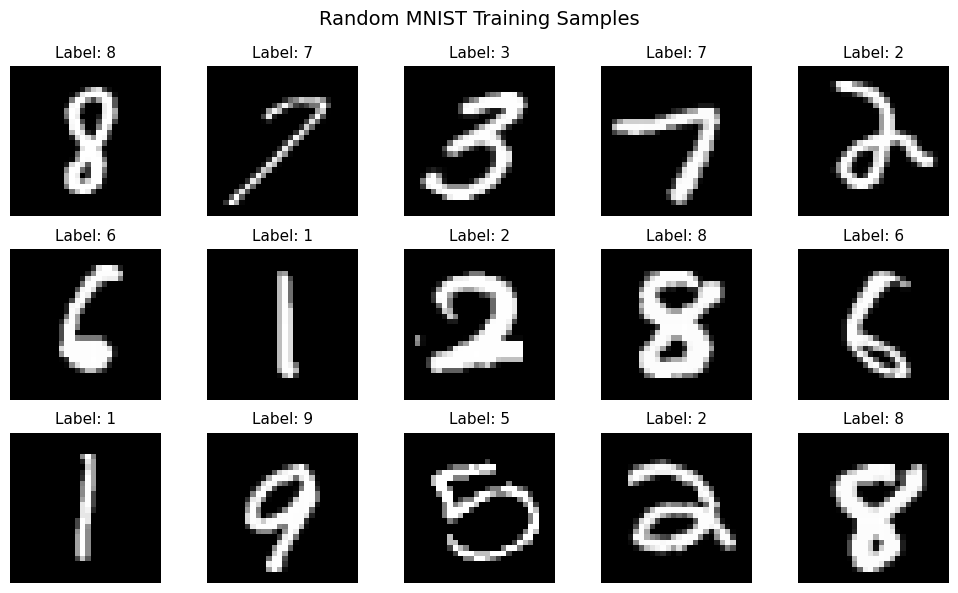

In [16]:
# ----------------------------------------------------
# Display random training samples
# ----------------------------------------------------

n_rows = 3
n_cols = 5
n_images = n_rows * n_cols

indices = np.random.choice(len(x_train), n_images, replace=False)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 6))

for ax, idx in zip(axes.flat, indices):

    image = x_train[idx]

    # Remove channel dimension if present
    if image.ndim == 3:
        image = image.squeeze()

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {y_train[idx]}", fontsize=11)
    ax.axis("off")

plt.suptitle("Random MNIST Training Samples", fontsize=14)

plt.tight_layout()
plt.show()

# **Designing a CNN**

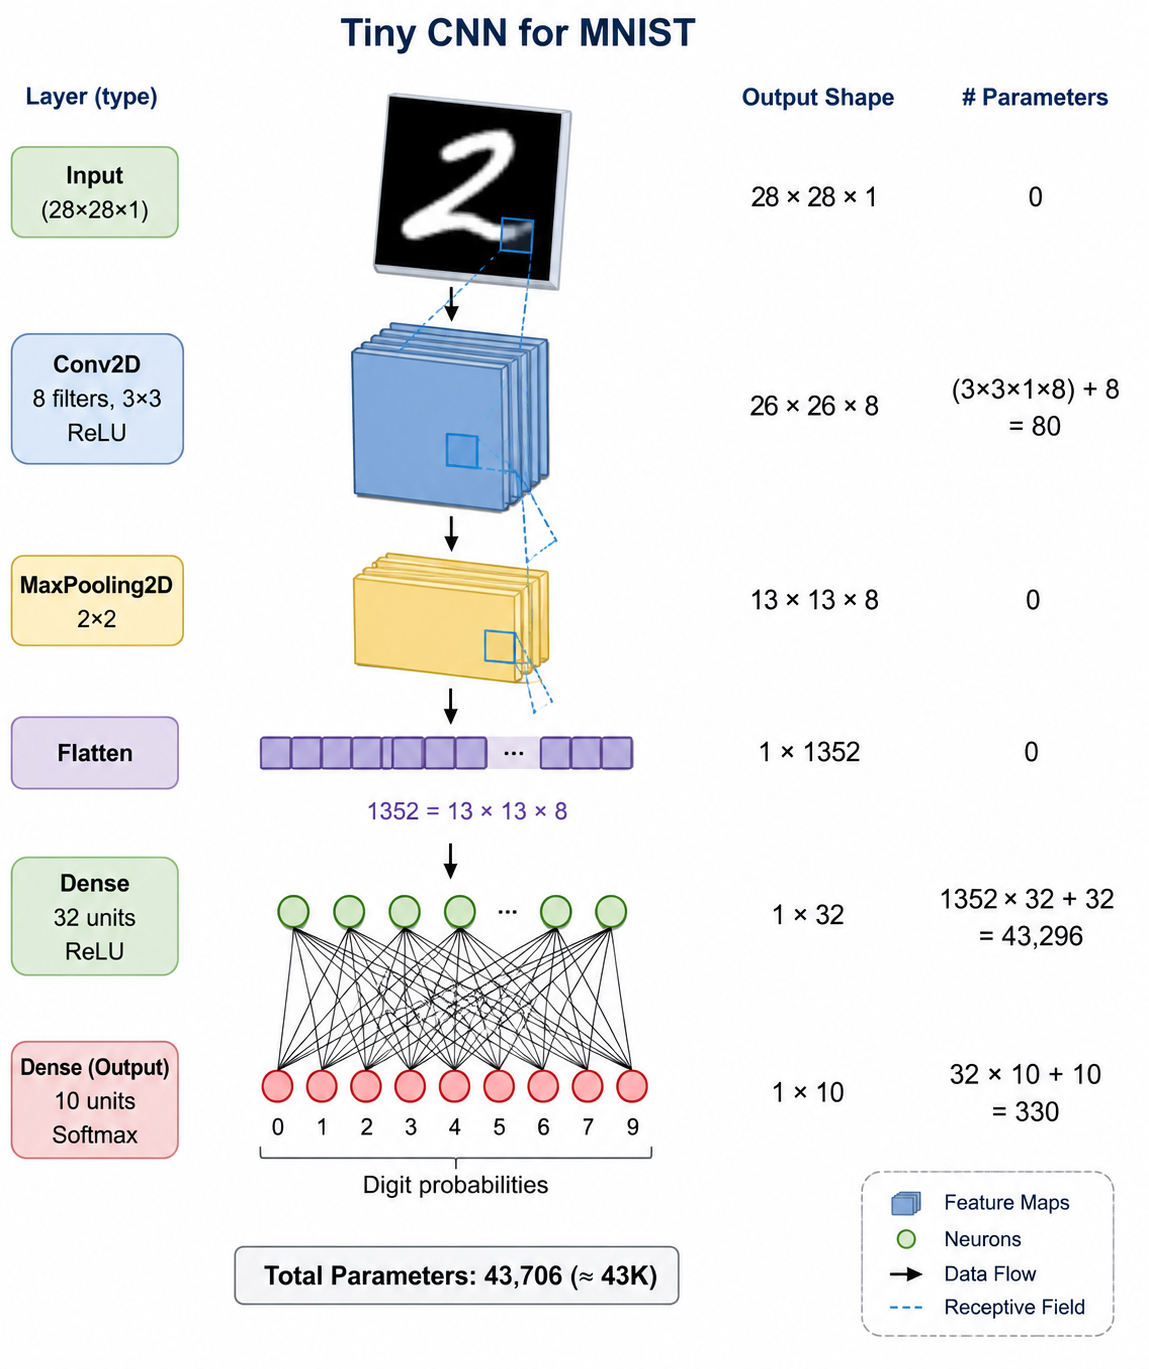

In [17]:
def create_tiny_cnn(input_shape=(28, 28, 1), num_classes=10):
    """
    Tiny CNN for MNIST classification.

    Architecture:
        Input (28×28×1)
            ↓
        Conv2D(8, 3×3, ReLU)
            ↓
        MaxPooling2D(2×2)
            ↓
        Flatten
            ↓
        Dense(32, ReLU)
            ↓
        Dense(10, Softmax)
    """

    model = Sequential([
        Input(shape=input_shape),

        Conv2D(
            filters=8,
            kernel_size=(3,3),
            activation="relu",
            padding="valid"
        ),

        MaxPooling2D(pool_size=(2,2)),

        Flatten(),

        Dense(32, activation="relu"),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

# **Training Process**

In [18]:
# Create the model
model = create_tiny_cnn()

# Display architecture
model.summary()

# Train
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=1
)

# Evaluate
loss, accuracy = model.evaluate(x_test, y_test)

print(f"Test Accuracy: {accuracy:.4f}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        43,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,706 (170.73 KB)

 Trainable params: 43,706 (170.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 23s 11ms/step - accuracy: 0.9266 - loss: 0.2608 - val_accuracy: 0.9630 - val_loss: 0.1217
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 12ms/step - accuracy: 0.9678 - loss: 0.1108 - val_accuracy: 0.9703 - val_loss: 0.0959
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9755 - loss: 0.0821 - val_accuracy: 0.9742 - val_loss: 0.0780
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9811 - loss: 0.0633 - val_accuracy: 0.9766 - val_loss: 0.0719
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.9842 - loss: 0.0511 - val_accuracy: 0.9803 - val_loss: 0.0598
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9803 - loss: 0.0598
Test Accuracy: 0.9803


# **Evaluating the learning process**

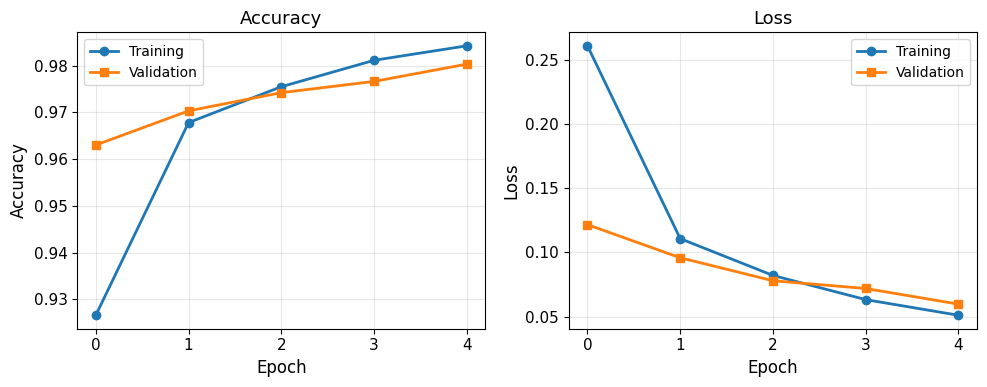

In [19]:
import matplotlib.pyplot as plt

# ==========================================================
# Plot learning curves
# ==========================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "legend.fontsize": 10
})

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# ----------------------------------------------------------
# Accuracy
# ----------------------------------------------------------

axes[0].plot(
    history.history["accuracy"],
    marker="o",
    linewidth=2,
    label="Training"
)

axes[0].plot(
    history.history["val_accuracy"],
    marker="s",
    linewidth=2,
    label="Validation"
)

axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].grid(alpha=0.3)
axes[0].legend()

# ----------------------------------------------------------
# Loss
# ----------------------------------------------------------

axes[1].plot(
    history.history["loss"],
    marker="o",
    linewidth=2,
    label="Training"
)

axes[1].plot(
    history.history["val_loss"],
    marker="s",
    linewidth=2,
    label="Validation"
)

axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()

plt.savefig(
    "learning_curve.pdf",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Figure**: Learning curves of the Tiny CNN trained on the MNIST dataset. Training and validation accuracy increase steadily while the corresponding losses decrease, indicating effective convergence and good generalization without evident overfitting.